In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
import pickle

TensorFlow version: 2.20.0


In [2]:
import warnings
warnings.filterwarnings('ignore')

!pip install -qqq numpy pandas matplotlib seaborn scikit-learn streamlit librosa

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import streamlit as st
import librosa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 38.5 MB/s eta 0:00:00


In [3]:
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found')
else:
  print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


In [5]:
training_set = tf.keras.utils.image_dataset_from_directory(
    '/content/PlantVillage/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 43444 files belonging to 38 classes.


In [6]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    '/content/PlantVillage/val',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 10861 files belonging to 38 classes.


In [7]:
for images, labels in training_set.take(1):
    print(images.dtype)
    print(images.numpy().min())
    print(images.numpy().max())

<dtype: 'float32'>
0.0
255.0


In [ ]:
## Model Training

In [4]:
!unzip /content/archive.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/PlantVillage/val/Soybean___healthy/52c7d07b-561b-4380-801a-3824e65a5135___RS_HL 3797.JPG  
  inflating: /content/PlantVillage/val/Soybean___healthy/53168d1c-ac90-4039-9eff-7479475a6b74___RS_HL 6355.JPG  
  inflating: /content/PlantVillage/val/Soybean___healthy/5344b09f-bbbe-4a2c-9345-d93dd4e69eb4___RS_HL 4693.JPG  
  inflating: /content/PlantVillage/val/Soybean___healthy/5361ba4a-351e-466c-99c5-8845f35c00df___RS_HL 2890.JPG  
  inflating: /content/PlantVillage/val/Soybean___healthy/537e5409-d824-4859-967f-3c502f13deec___RS_HL 5474.JPG  
  inflating: /content/PlantVillage/val/Soybean___healthy/538969da-545b-4bce-bc1d-0932898dc5e6___RS_HL 5230.JPG  
  inflating: /content/PlantVillage/val/Soybean___healthy/538ccfe2-1509-40d7-beae-ae7cf84e1e5d___RS_HL 3717.JPG  
  inflating: /content/PlantVillage/val/Soybean___healthy/5397bf6a-aeeb-4f1c-b554-bdb604bb23c3___RS_HL 6508.JPG  
  inflating: /content/PlantVillage/val/Soybea

In [ ]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [ ]:
model = Sequential()

# Block 1
model.add(Conv2D(32, 3, padding='same', activation='relu', input_shape=(128,128,3)))
model.add(Conv2D(32, 3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

# Block 2
model.add(Conv2D(64, 3, padding='same', activation='relu'))
model.add(Conv2D(64, 3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

# Block 3
model.add(Conv2D(128, 3, padding='same', activation='relu'))
model.add(Conv2D(128, 3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

# Block 4
model.add(Conv2D(256, 3, padding='same', activation='relu'))
model.add(Conv2D(256, 3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

# Block 5
model.add(Conv2D(512, 3, padding='same', activation='relu'))
model.add(Conv2D(512, 3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Dropout(0.25))          # light dropout before dense head
model.add(Flatten())
model.add(Dense(1500, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(38, activation='softmax'))

In [ ]:
model.compile(optimizer='adam' , loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10 , callbacks=[early_stop])

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 108s 68ms/step - accuracy: 0.4529 - loss: 1.9762 - val_accuracy: 0.6892 - val_loss: 0.9689
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 82s 61ms/step - accuracy: 0.7407 - loss: 0.8303 - val_accuracy: 0.8143 - val_loss: 0.5799
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 81s 60ms/step - accuracy: 0.8202 - loss: 0.5599 - val_accuracy: 0.8530 - val_loss: 0.4626
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 80s 59ms/step - accuracy: 0.8499 - loss: 0.4688 - val_accuracy: 0.8424 - val_loss: 0.5028
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 84s 60ms/step - accuracy: 0.8730 - loss: 0.3911 - val_accuracy: 0.8780 - val_loss: 0.3809
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 84s 62ms/step - accuracy: 0.8857 - loss: 0.3561 - val_accuracy: 0.8476 - val_loss: 0.5034
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 81s 60ms/step - accuracy: 0.8882 - loss: 0.3488 - val_accuracy: 0.8684 - val_loss: 0.4309
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 81s 60ms/step - accuracy: 0.8997 

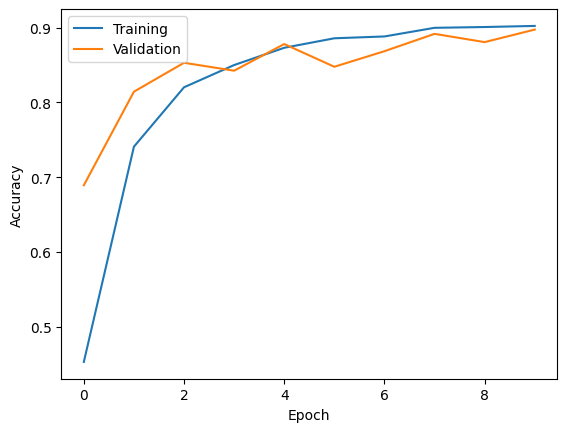

In [ ]:
plt.plot(training_history.history['accuracy'])
plt.plot(training_history.history['val_accuracy'])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training", "Validation"])

plt.show()

Accuracy

In [ ]:
train_loss,train_acc = model.evaluate(training_set)

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - accuracy: 0.9423 - loss: 0.1726


In [ ]:
print(train_loss,train_acc)

0.17264597117900848 0.9423395395278931


In [ ]:
val_loss,val_acc = model.evaluate(validation_set)

340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8973 - loss: 0.3370


In [ ]:
print(val_loss,val_acc)

0.33699125051498413 0.8973391056060791


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [ ]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    '/content/PlantVillage/val',
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(128,128),
    shuffle=False
)

Found 10861 files belonging to 38 classes.


In [ ]:
import numpy as np

y_true = np.concatenate([labels.numpy() for images, labels in validation_set])

# Convert one-hot → class index
y_true = np.argmax(y_true, axis=1)

In [ ]:
y_true = []

for images, labels in validation_set:
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)

y_pred_prob = model.predict(validation_set)

y_pred = np.argmax(y_pred_prob, axis=1)






340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step


In [ ]:
class_names = validation_set.class_names

print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [ ]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[  91    0    0 ...    0    0    0]
 [   0  115    1 ...    0    0    0]
 [   0    1   40 ...    0    0    0]
 ...
 [   0    0    0 ... 1036    1    1]
 [   0    0    0 ...    1   66    0]
 [   0    0    0 ...    0    0  279]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.88      0.72      0.79       126
                                 Apple___Black_rot       0.98      0.92      0.95       125
                          Apple___Cedar_apple_rust       0.74      0.73      0.73        55
                                   Apple___healthy       0.93      0.79      0.86       329
                               Blueberry___healthy       0.92      0.94      0.93       300
          Cherry_(including_sour)___Powdery_mildew       0.96      0.96      0.96       210
                 Cherry_(including_sour)___healthy       0.90      0.94      0.92       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.76      0.63      0.69       103
                       Corn_(maize)___Common_rust_       0.99      0.96      0.97       239
               Corn_(maize)___Northern_Leaf_Blight       0.73      0.92      0.

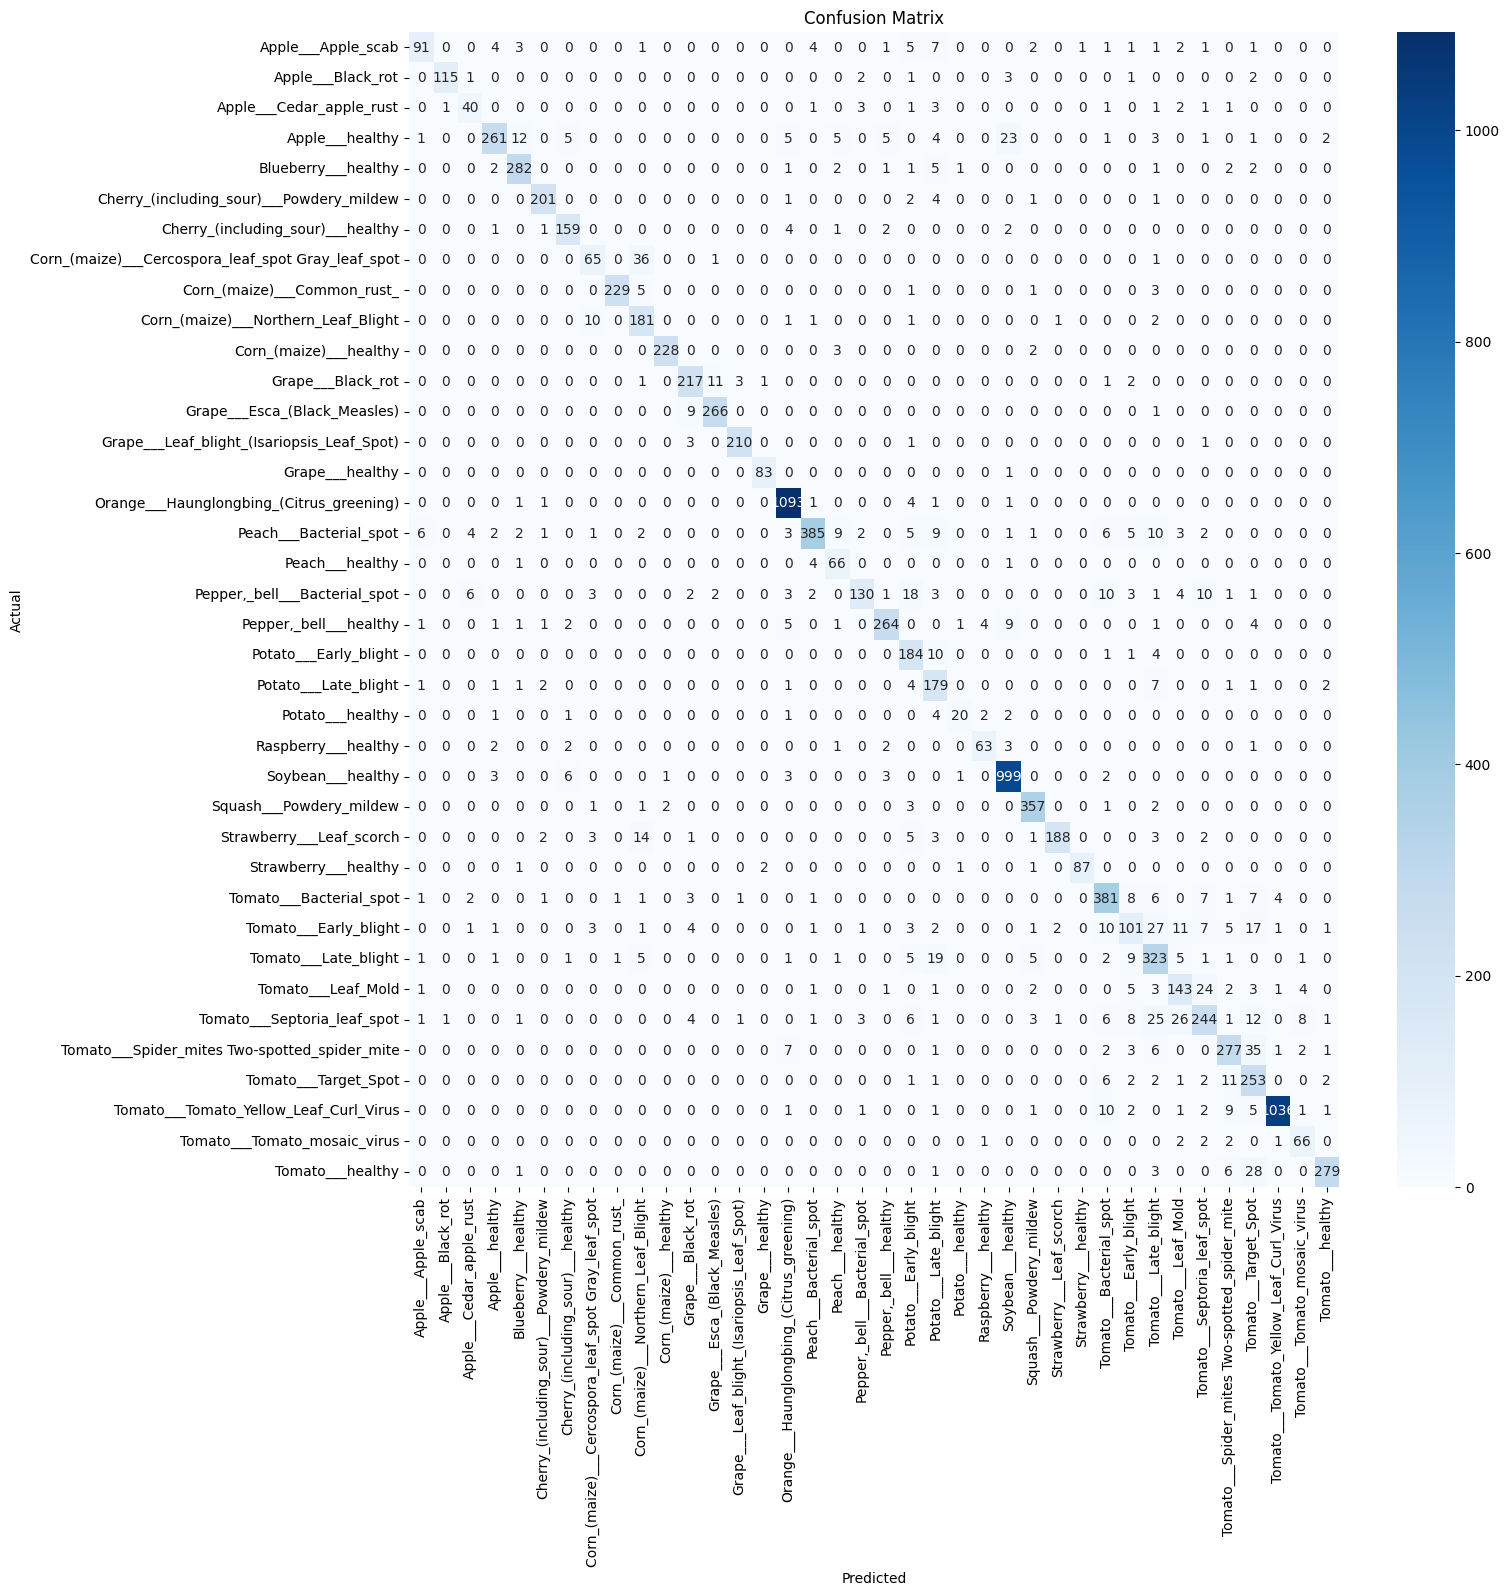

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,15))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Save Model

In [ ]:
model.save("trained_model.keras")

In [ ]:
# Load the saved Keras model
loaded_model = tf.keras.models.load_model('trained_model.keras')

# Save the loaded model as a pickle file
with open('trained_model.pkl', 'wb') as file:
    pickle.dump(loaded_model, file)

print("Model saved as trained_model.pkl")

Model saved as trained_model.pkl


In [ ]:
training_history.history

{'accuracy': [0.4529048800468445,
  0.7407467365264893,
  0.8201823234558105,
  0.8499217629432678,
  0.8730089068412781,
  0.8857149481773376,
  0.8881548643112183,
  0.8997099995613098,
  0.9007688164710999,
  0.9022419452667236],
 'loss': [1.9762343168258667,
  0.8302959203720093,
  0.559938371181488,
  0.46880748867988586,
  0.3911188244819641,
  0.3560938835144043,
  0.34882768988609314,
  0.31187307834625244,
  0.3067053556442261,
  0.3068452477455139],
 'val_accuracy': [0.689163088798523,
  0.8142896890640259,
  0.8529601097106934,
  0.8423717617988586,
  0.8780038952827454,
  0.8476199507713318,
  0.8684283494949341,
  0.8916305899620056,
  0.8805819153785706,
  0.8973391056060791],
 'val_loss': [0.968902587890625,
  0.5799111127853394,
  0.46256110072135925,
  0.5028088688850403,
  0.38085299730300903,
  0.5033900737762451,
  0.4309307038784027,
  0.3479793071746826,
  0.3965100347995758,
  0.33699148893356323]}

In [ ]:
#Recording History in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

Download Model

In [ ]:
from google.colab import files

files.download('trained_model.keras')
files.download('training_hist.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

download pickle file

In [ ]:
from google.colab import files

files.download('trained_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model Test